<a href="https://colab.research.google.com/github/johncase17/Data-Science-Project-1/blob/main/analysis_seeded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

NOTEBOOK_DIR   = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL'
KPCONV_DIR     = os.path.join(NOTEBOOK_DIR, 'results', 'kpconv')
UNET_DIR       = os.path.join(NOTEBOOK_DIR, 'results', 'unet')
HYBRID_DIR     = os.path.join(NOTEBOOK_DIR, 'results', 'hybrid')
SEEDS          = [42, 123, 456]

# ── SemanticKITTI 19-class names (KPConv order) ──────────────────
KPCONV_CLASSES = [
    'car','bicycle','motorcycle','truck','other-vehicle',
    'person','bicyclist','motorcyclist','road','parking',
    'sidewalk','other-ground','building','fence',
    'vegetation','trunk','terrain','pole','traffic-sign'
]

# ── 5 terrain classes ─────────────────────────────────────────────
TERRAIN_CLASSES = ['Unknown','Flat_Traversable','Slope','Obstacle','Void']

# ── Mapping: KPConv 19-class index → terrain class index ─────────
# Based on RAW_TO_TERRAIN mapping used in hybrid/unet
KPCONV_TO_TERRAIN = {
    0:  3,  # car          → Obstacle
    1:  3,  # bicycle      → Obstacle
    2:  3,  # motorcycle   → Obstacle
    3:  3,  # truck        → Obstacle
    4:  3,  # other-vehicle→ Obstacle
    5:  3,  # person       → Obstacle
    6:  3,  # bicyclist    → Obstacle
    7:  3,  # motorcyclist → Obstacle
    8:  1,  # road         → Flat/Traversable
    9:  1,  # parking      → Flat/Traversable
    10: 1,  # sidewalk     → Flat/Traversable
    11: 0,  # other-ground → Unknown
    12: 3,  # building     → Obstacle
    13: 3,  # fence        → Obstacle
    14: 2,  # vegetation   → Slope
    15: 3,  # trunk        → Obstacle
    16: 2,  # terrain      → Slope
    17: 3,  # pole         → Obstacle
    18: 3,  # traffic-sign → Obstacle
}

print('Setup complete.')
print(f'KPConv  : {KPCONV_DIR}')
print(f'U-Net   : {UNET_DIR}')
print(f'Hybrid  : {HYBRID_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.
KPConv  : /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/kpconv
U-Net   : /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/unet
Hybrid  : /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/hybrid


In [92]:
import zipfile, time

ZIP_PATH = os.path.join(NOTEBOOK_DIR, 'semkitti_research.zip')
DATA_DIR = '/content/KPConv-PyTorch/Data/SemanticKitti'
SEQ_DST  = os.path.join(DATA_DIR, 'sequences')
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(SEQ_DST):
    print('Extracting sequences...')
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        members = [m for m in z.namelist()
                   if 'semantickitti_subsampled/sequences/' in m]
        for member in members:
            rel = member.split('semantickitti_subsampled/sequences/')[-1]
            if not rel: continue
            dst = os.path.join(SEQ_DST, rel)
            if member.endswith('/'):
                os.makedirs(dst, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(dst), exist_ok=True)
                with z.open(member) as src, open(dst, 'wb') as out:
                    out.write(src.read())
    print(f'Done in {time.time()-t0:.0f}s')
else:
    print('Already extracted.')

SEQ_ROOT = SEQ_DST
print(f'SEQ_ROOT: {SEQ_ROOT}')

Already extracted.
SEQ_ROOT: /content/KPConv-PyTorch/Data/SemanticKitti/sequences


In [93]:
HYBRID_FIELDNAMES = (
    ['model','seed','epoch','train_loss','val_loss','lr','epoch_time_s',
     'val_miou','best_val_miou','best_epoch','train_miou']
    + [f'val_iou_{c}' for c in ['Unknown','Flat_Traversable','Slope','Obstacle','Void']]
    + ['total_params','gpu_name','torch_version','cuda_version','run_start_time']
)

UNET_FIELDNAMES = (
    ['model','seed','epoch','train_loss','val_loss','lr','grad_norm','epoch_time_s',
     'gpu_util_pct','val_miou','val_overall_acc','best_val_miou','best_epoch',
     'conf_matrix_json','total_params','gpu_name','torch_version','cuda_version','run_start_time']
    + [f'val_iou_{c}' for c in ['Unknown','Flat_Traversable','Slope','Obstacle','Void']]
    + [f'val_acc_{c}' for c in ['Unknown','Flat_Traversable','Slope','Obstacle','Void']]
    + [f'val_precision_{c}' for c in ['Unknown','Flat_Traversable','Slope','Obstacle','Void']]
    + [f'val_recall_{c}' for c in ['Unknown','Flat_Traversable','Slope','Obstacle','Void']]
    + [f'val_f1_{c}' for c in ['Unknown','Flat_Traversable','Slope','Obstacle','Void']]
)

def load_csvs(results_dir, seeds, fieldnames=None):
    dfs = {}
    for seed in seeds:
        path = os.path.join(results_dir, str(seed), 'metrics.csv')
        if os.path.exists(path):
            df = pd.read_csv(path, header=0)
            if df.columns[0] != 'model' and fieldnames is not None:
                df = pd.read_csv(path, header=None, names=fieldnames)
            dfs[seed] = df
            print(f'  seed {seed}: {len(df)} epochs, best mIoU={df["val_miou"].max():.4f}')
        else:
            print(f'  seed {seed}: NOT FOUND')
    return dfs

print('KPConv:')
kpconv_dfs = load_csvs(KPCONV_DIR, SEEDS)
print('U-Net:')
unet_dfs   = load_csvs(UNET_DIR,   SEEDS, fieldnames=UNET_FIELDNAMES)
print('Hybrid:')
hybrid_dfs = load_csvs(HYBRID_DIR, SEEDS, fieldnames=HYBRID_FIELDNAMES)

KPConv:
  seed 42: 571 epochs, best mIoU=0.5604
  seed 123: 1041 epochs, best mIoU=0.5609
  seed 456: 1104 epochs, best mIoU=0.5513
U-Net:
  seed 42: 30 epochs, best mIoU=0.6638
  seed 123: 30 epochs, best mIoU=0.6599
  seed 456: 30 epochs, best mIoU=0.6646
Hybrid:
  seed 42: 208 epochs, best mIoU=0.7559
  seed 123: 194 epochs, best mIoU=0.7523
  seed 456: 250 epochs, best mIoU=0.7594


In [94]:
import pandas as pd, os
NOTEBOOK_DIR = '/content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL'
df = pd.read_csv(os.path.join(NOTEBOOK_DIR, 'results', 'hybrid', '42', 'metrics.csv'))
print(df.columns.tolist())

['hybrid', '42', '1', '0.935671', '0.619973', '0.00029999', '126.53', '0.514583', '0.514583.1', '1.1', '0.355515', '0.907918', '0.526571', '0.410182', '0.69674', '0.031504', '8778333', 'Tesla T4', '2.11.0+cu128', '12.8', '2026-07-09T23:19:05']


In [95]:
print(kpconv_dfs[42].columns.tolist())
print(list(hybrid_dfs.keys()))
print(list(unet_dfs.keys()))

['model', 'seed', 'epoch', 'train_loss', 'train_acc', 'lr', 'epoch_time_s', 'val_miou', 'best_val_miou', 'best_epoch', 'val_iou_car', 'val_iou_bicycle', 'val_iou_motorcycle', 'val_iou_truck', 'val_iou_other-vehicle', 'val_iou_person', 'val_iou_bicyclist', 'val_iou_motorcyclist', 'val_iou_road', 'val_iou_parking', 'val_iou_sidewalk', 'val_iou_other-ground', 'val_iou_building', 'val_iou_fence', 'val_iou_vegetation', 'val_iou_trunk', 'val_iou_terrain', 'val_iou_pole', 'val_iou_traffic-sign', 'total_params', 'gpu_name', 'torch_version', 'cuda_version', 'run_start_time']
[42, 123, 456]
[42, 123, 456]


In [96]:
# ── Load KPConv 5-class results from eval ────────────────────────
kpconv_5class = {}
for seed in SEEDS:
    iou_path = os.path.join(KPCONV_DIR, str(seed), 'val_preds_best', 'iou_5class.npy')
    if os.path.exists(iou_path):
        iou = np.load(iou_path)
        kpconv_5class[seed] = iou
        print(f'KPConv seed {seed}: mIoU={iou.mean():.4f}')
    else:
        print(f'KPConv seed {seed}: iou_5class.npy not found')

KPConv seed 42: mIoU=0.5420
KPConv seed 123: mIoU=0.5310
KPConv seed 456: mIoU=0.5322


In [97]:
def remap_ious_to_terrain(ious_19, mapping, n_terrain=5):
    """
    For each epoch, average IoUs of 19-class predictions that map
    to the same terrain class. Returns array of shape (epochs, 5).
    """
    epochs = ious_19.shape[0]
    terrain_ious = np.zeros((epochs, n_terrain), dtype=np.float64)
    counts       = np.zeros(n_terrain, dtype=np.int32)

    for cls_19, cls_5 in mapping.items():
        terrain_ious[:, cls_5] += ious_19[:, cls_19]
        counts[cls_5] += 1

    for c in range(n_terrain):
        if counts[c] > 0:
            terrain_ious[:, c] /= counts[c]

    return terrain_ious

kpconv_terrain_ious = {}
for seed, arr in kpconv_ious.items():
    kpconv_terrain_ious[seed] = remap_ious_to_terrain(arr, KPCONV_TO_TERRAIN)
    remapped_miou = kpconv_terrain_ious[seed].mean(1).max()
    print(f'Seed {seed}: best remapped mIoU (5-class) = {remapped_miou:.4f}')


Seed 42: best remapped mIoU (5-class) = 0.3960
Seed 123: best remapped mIoU (5-class) = 0.3973
Seed 456: best remapped mIoU (5-class) = 0.3916


In [98]:
def best_miou(dfs):
    return {seed: df['val_miou'].max() for seed, df in dfs.items()}

def summary_row(name, miou_dict):
    vals = list(miou_dict.values())
    return {
        'Model': name,
        'Seed 42':  f"{miou_dict.get(42,  float('nan')):.4f}",
        'Seed 123': f"{miou_dict.get(123, float('nan')):.4f}",
        'Seed 456': f"{miou_dict.get(456, float('nan')):.4f}",
        'Mean':     f"{np.mean(vals):.4f}",
        'Std':      f"{np.std(vals):.4f}",
    }

# KPConv remapped to 5 classes
kpconv_remapped_best = {seed: arr.mean() for seed, arr in kpconv_5class.items()}

rows = [
    summary_row('U-Net (5-class)',          best_miou(unet_dfs)),
    summary_row('Hybrid KPConv+UNet (5-class)', best_miou(hybrid_dfs)),
    summary_row('KPConv (19-class)',         best_miou(kpconv_dfs)),
    summary_row('KPConv (remapped 5-class)', kpconv_remapped_best),
]

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))
df_summary.to_csv(os.path.join(NOTEBOOK_DIR, 'results', 'summary_table.csv'), index=False)
print('\nSaved to summary_table.csv')


                       Model Seed 42 Seed 123 Seed 456   Mean    Std
             U-Net (5-class)  0.6638   0.6599   0.6646 0.6628 0.0020
Hybrid KPConv+UNet (5-class)  0.7559   0.7523   0.7594 0.7559 0.0029
           KPConv (19-class)  0.5604   0.5609   0.5513 0.5575 0.0044
   KPConv (remapped 5-class)  0.5420   0.5310   0.5322 0.5351 0.0049

Saved to summary_table.csv


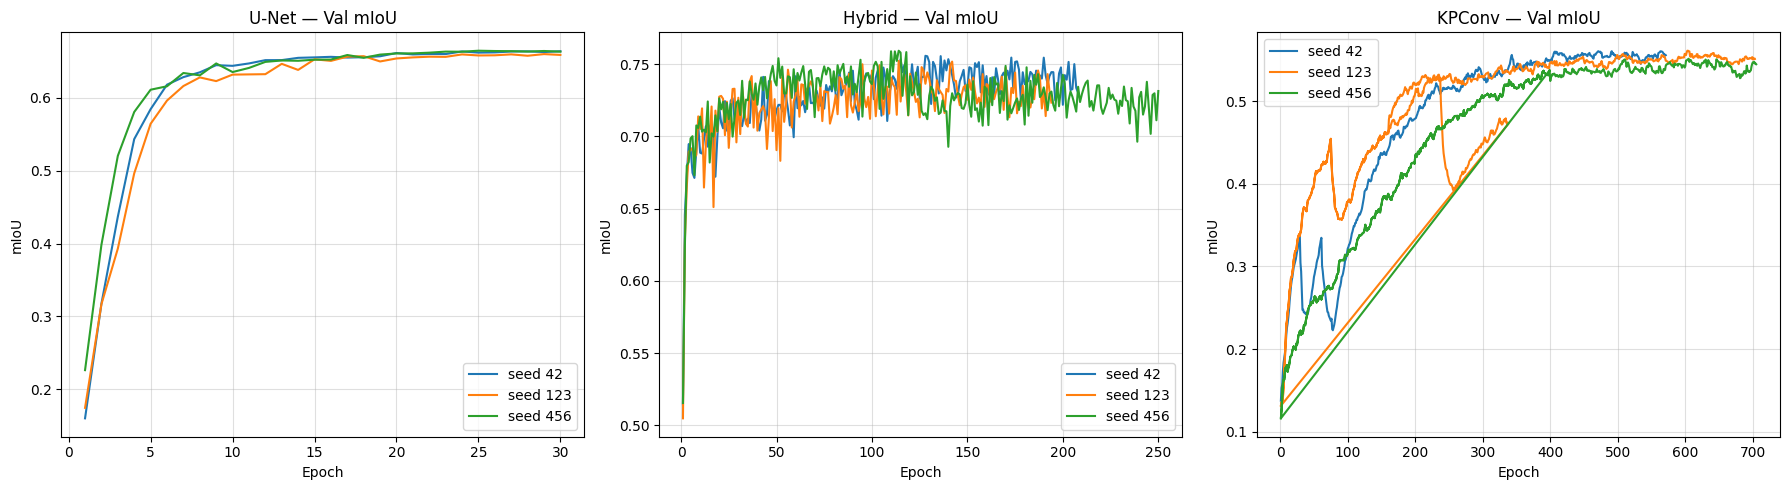

Saved to /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/convergence_all_models.png


In [99]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_data = [
    ('U-Net',   unet_dfs,   axes[0]),
    ('Hybrid',  hybrid_dfs, axes[1]),
    ('KPConv',  kpconv_dfs, axes[2]),
]

for name, dfs, ax in model_data:
    for seed, df in dfs.items():
        ax.plot(df['epoch'], df['val_miou'], label=f'seed {seed}')
    ax.set_title(f'{name} — Val mIoU')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('mIoU')
    ax.legend()
    ax.grid(alpha=0.4)

plt.tight_layout()
out = os.path.join(NOTEBOOK_DIR, 'results', 'convergence_all_models.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out}')


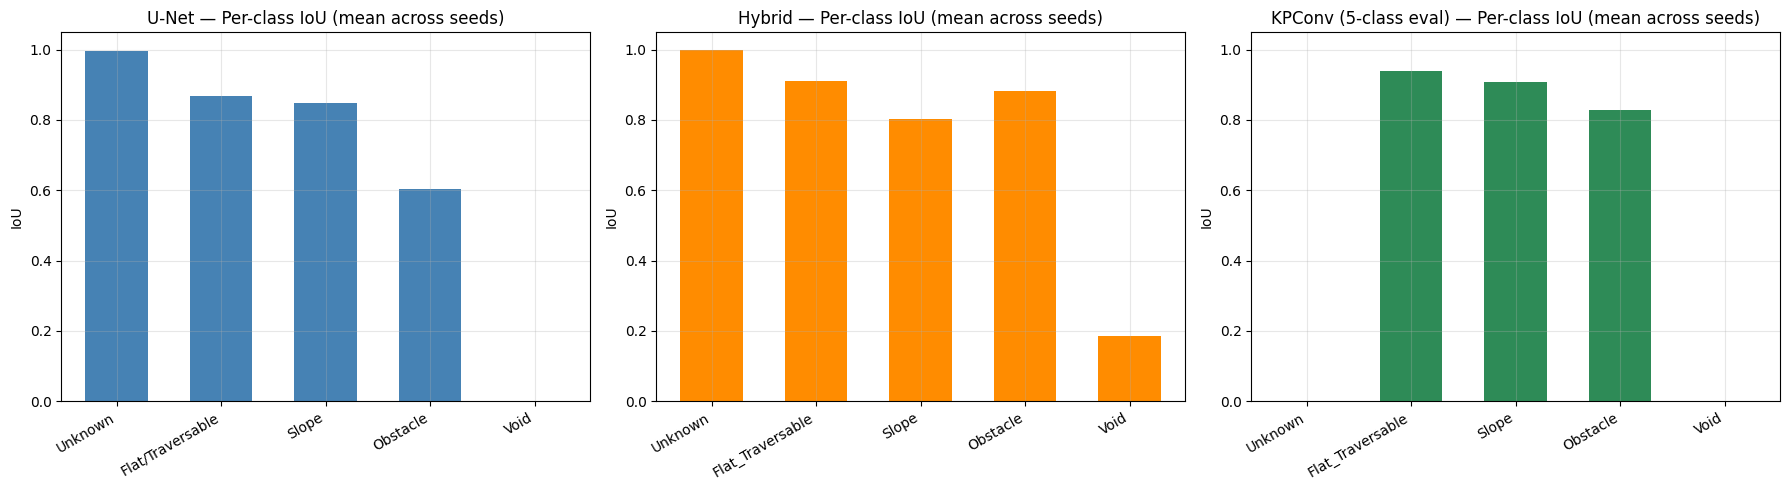

Saved to /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/per_class_iou.png


In [100]:
def get_best_class_ious(dfs, class_cols):
    per_seed = []
    for seed, df in dfs.items():
        best_row = df.loc[df['val_miou'].idxmax()]
        per_seed.append([best_row[c] for c in class_cols if c in best_row])
    return np.mean(per_seed, axis=0)

unet_class_cols   = [c for c in unet_dfs[42].columns   if c.startswith('val_iou_')]
hybrid_class_cols = [c for c in hybrid_dfs[42].columns if c.startswith('val_iou_')]
unet_labels   = [c.replace('val_iou_','') for c in unet_class_cols]
hybrid_labels = [c.replace('val_iou_','') for c in hybrid_class_cols]

unet_class_ious   = get_best_class_ious(unet_dfs,   unet_class_cols)
hybrid_class_ious = get_best_class_ious(hybrid_dfs, hybrid_class_cols)

kpconv_terrain_mean = np.mean([kpconv_5class[seed] for seed in SEEDS], axis=0)

y_max = max(unet_class_ious.max(), hybrid_class_ious.max(), kpconv_terrain_mean.max()) + 0.05

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(TERRAIN_CLASSES))
w = 0.6

for ax, ious, labels, color, title in [
    (axes[0], unet_class_ious,    unet_labels,       'steelblue',  'U-Net'),
    (axes[1], hybrid_class_ious,  hybrid_labels,     'darkorange', 'Hybrid'),
    (axes[2], kpconv_terrain_mean,TERRAIN_CLASSES,   'seagreen',   'KPConv (5-class eval)'),
]:
    ax.bar(x, ious, color=color, width=w)
    ax.set_title(f'{title} — Per-class IoU (mean across seeds)')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylabel('IoU'); ax.set_ylim(0, y_max); ax.grid(alpha=0.3)

plt.tight_layout()
out = os.path.join(NOTEBOOK_DIR, 'results', 'per_class_iou.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out}')

In [108]:
# ── Per-class IoU table ───────────────────────────────────────────
unet_per_seed   = np.array([
    [unet_dfs[seed].loc[unet_dfs[seed]['val_miou'].idxmax(), c]
     for c in unet_class_cols] for seed in SEEDS])
hybrid_per_seed = np.array([
    [hybrid_dfs[seed].loc[hybrid_dfs[seed]['val_miou'].idxmax(), c]
     for c in hybrid_class_cols] for seed in SEEDS])
kpconv_per_seed = np.array([kpconv_5class[seed] for seed in SEEDS])

unet_std   = unet_per_seed.std(0)
hybrid_std = hybrid_per_seed.std(0)
kpconv_std = kpconv_per_seed.std(0)

rows = []
for c, name in enumerate(TERRAIN_CLASSES):
    rows.append({
        'Class':   name,
        'U-Net':   f'{unet_class_ious[c]:.4f} ± {unet_std[c]:.4f}',
        'Hybrid':  f'{hybrid_class_ious[c]:.4f} ± {hybrid_std[c]:.4f}',
        'KPConv':  f'{kpconv_terrain_mean[c]:.4f} ± {kpconv_std[c]:.4f}',
    })

meaningful = [1, 2, 3]
rows.append({
    'Class':  'mIoU (all)',
    'U-Net':  f'{unet_class_ious.mean():.4f} ± {unet_per_seed.mean(1).std():.4f}',
    'Hybrid': f'{hybrid_class_ious.mean():.4f} ± {hybrid_per_seed.mean(1).std():.4f}',
    'KPConv': f'{kpconv_terrain_mean.mean():.4f} ± {kpconv_per_seed.mean(1).std():.4f}',
})
rows.append({
    'Class':  'mIoU (excl. Unknown+Void)',
    'U-Net':  f'{unet_class_ious[meaningful].mean():.4f} ± {unet_per_seed[:,meaningful].mean(1).std():.4f}',
    'Hybrid': f'{hybrid_class_ious[meaningful].mean():.4f} ± {hybrid_per_seed[:,meaningful].mean(1).std():.4f}',
    'KPConv': f'{kpconv_terrain_mean[meaningful].mean():.4f} ± {kpconv_per_seed[:,meaningful].mean(1).std():.4f}',
})

df_class = pd.DataFrame(rows)
print(df_class.to_string(index=False))
df_class.to_csv(os.path.join(NOTEBOOK_DIR, 'results', 'per_class_table.csv'), index=False)
print('\nSaved to per_class_table.csv')

                    Class           U-Net          Hybrid          KPConv
                  Unknown 0.9964 ± 0.0001 0.9989 ± 0.0000 0.0002 ± 0.0001
         Flat_Traversable 0.8679 ± 0.0013 0.9114 ± 0.0057 0.9390 ± 0.0019
                    Slope 0.8468 ± 0.0037 0.8033 ± 0.0043 0.9084 ± 0.0102
                 Obstacle 0.6027 ± 0.0051 0.8813 ± 0.0031 0.8276 ± 0.0167
                     Void 0.0000 ± 0.0000 0.1844 ± 0.0052 0.0000 ± 0.0000
               mIoU (all) 0.6628 ± 0.0020 0.7559 ± 0.0029 0.5351 ± 0.0049
mIoU (excl. Unknown+Void) 0.7725 ± 0.0034 0.8653 ± 0.0032 0.8917 ± 0.0082

Saved to per_class_table.csv


In [109]:
rows = []
for c, name in enumerate(TERRAIN_CLASSES):
    rows.append({
        'Class':   name,
        'U-Net':   f'{unet_class_ious[c]:.4f}',
        'Hybrid':  f'{hybrid_class_ious[c]:.4f}',
        'KPConv':  f'{kpconv_terrain_mean[c]:.4f}',
    })

meaningful = [1, 2, 3]
rows.append({
    'Class':  'mIoU (all)',
    'U-Net':  f'{unet_class_ious.mean():.4f}',
    'Hybrid': f'{hybrid_class_ious.mean():.4f}',
    'KPConv': f'{kpconv_terrain_mean.mean():.4f}',
})
rows.append({
    'Class':  'mIoU (excl. Unknown+Void)',
    'U-Net':  f'{unet_class_ious[meaningful].mean():.4f}',
    'Hybrid': f'{hybrid_class_ious[meaningful].mean():.4f}',
    'KPConv': f'{kpconv_terrain_mean[meaningful].mean():.4f}',
})

df_class_mean = pd.DataFrame(rows)
print(df_class_mean.to_string(index=False))
df_class_mean.to_csv(os.path.join(NOTEBOOK_DIR, 'results', 'per_class_table_mean.csv'), index=False)
print('\nSaved to per_class_table_mean.csv')

                    Class  U-Net Hybrid KPConv
                  Unknown 0.9964 0.9989 0.0002
         Flat_Traversable 0.8679 0.9114 0.9390
                    Slope 0.8468 0.8033 0.9084
                 Obstacle 0.6027 0.8813 0.8276
                     Void 0.0000 0.1844 0.0000
               mIoU (all) 0.6628 0.7559 0.5351
mIoU (excl. Unknown+Void) 0.7725 0.8653 0.8917

Saved to per_class_table_mean.csv


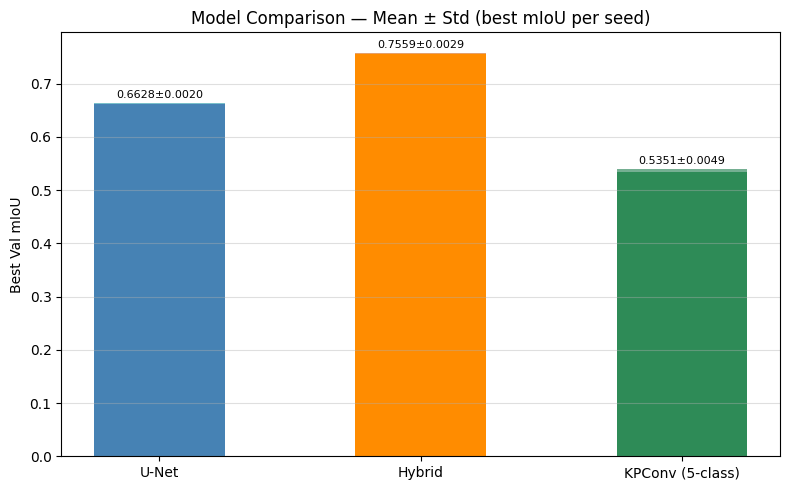

Saved to /content/drive/MyDrive/Colab Notebooks/TerrainClassificationDL/results/model_comparison.png


In [102]:
fig, ax = plt.subplots(figsize=(8, 5))

models     = ['U-Net', 'Hybrid', 'KPConv (5-class)']
bar_colors = ['steelblue', 'darkorange', 'seagreen']
std_colors = ['#2196a8', '#d4620a', '#1a7a4a']

means = []
stds  = []

for dfs in [unet_dfs, hybrid_dfs]:
    bests = [df['val_miou'].max() for df in dfs.values()]
    means.append(np.mean(bests))
    stds.append(np.std(bests))

# KPConv — use proper 5-class eval
kpconv_bests = [kpconv_5class[seed].mean() for seed in SEEDS if seed in kpconv_5class]
means.append(np.mean(kpconv_bests))
stds.append(np.std(kpconv_bests))

x = np.arange(len(models))
w = 0.5

for i, (mean, std, bc, sc) in enumerate(zip(means, stds, bar_colors, std_colors)):
    ax.bar(x[i], mean, color=bc, width=w)
    ax.bar(x[i], std,  color=sc, width=w, bottom=mean, alpha=0.6)
    ax.text(x[i], mean + std + 0.005, f'{mean:.4f}±{std:.4f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Best Val mIoU')
ax.set_title('Model Comparison — Mean ± Std (best mIoU per seed)')
ax.grid(alpha=0.4, axis='y')

plt.tight_layout()
out = os.path.join(NOTEBOOK_DIR, 'results', 'model_comparison.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {out}')

In [103]:
# ── Overall mIoU table — all seeds + mean ± std ──────────────────
rows = []
for model_name, dfs, kpconv_flag in [
    ('U-Net',  unet_dfs,   False),
    ('Hybrid', hybrid_dfs, False),
    ('KPConv', None,       True),
]:
    if kpconv_flag:
        bests = {seed: kpconv_5class[seed].mean() for seed in SEEDS if seed in kpconv_5class}
    else:
        bests = {seed: dfs[seed]['val_miou'].max() for seed in SEEDS if seed in dfs}

    vals = list(bests.values())
    row  = {'Model': model_name}
    for seed in SEEDS:
        row[f'Seed {seed}'] = f'{bests.get(seed, float("nan")):.4f}'
    row['Mean'] = f'{np.mean(vals):.4f}'
    row['Std']  = f'{np.std(vals):.4f}'
    rows.append(row)

df_overall = pd.DataFrame(rows)
print(df_overall.to_string(index=False))
df_overall.to_csv(os.path.join(NOTEBOOK_DIR, 'results', 'overall_miou_table.csv'), index=False)
print('\nSaved to overall_miou_table.csv')

 Model Seed 42 Seed 123 Seed 456   Mean    Std
 U-Net  0.6638   0.6599   0.6646 0.6628 0.0020
Hybrid  0.7559   0.7523   0.7594 0.7559 0.0029
KPConv  0.5420   0.5310   0.5322 0.5351 0.0049

Saved to overall_miou_table.csv


In [104]:
print(kpconv_bests)
print(means)

[np.float64(0.5419685234916958), np.float64(0.530975375241191), np.float64(0.5322325510938255)]
[np.float64(0.66277), np.float64(0.7558626666666667), np.float64(0.5350588166089041)]


In [105]:
!pip install plyfile -q

In [106]:
from plyfile import PlyData
from scipy.spatial import cKDTree

def compute_5class_iou(seed):
    SEQ_ROOT      = '/content/KPConv-PyTorch/Data/SemanticKitti/sequences'
    val_preds_dir = os.path.join(KPCONV_DIR, str(seed), 'val_preds_best', 'predictions')
    pred_files    = sorted(f for f in os.listdir(val_preds_dir) if f.endswith('.npy'))

    inter = np.zeros(5, np.float64)
    union = np.zeros(5, np.float64)

    for fname in pred_files:
        parts  = fname.replace('.npy', '').split('_')
        seq    = parts[0]
        frame  = parts[1][:6]  # 6-digit label filename

        lbl_path = os.path.join(SEQ_ROOT, seq, 'labels', f'{frame}.label')
        bin_path = os.path.join(SEQ_ROOT, seq, 'velodyne', f'{frame}.bin')
        ply_path = os.path.join(val_preds_dir, fname.replace('.npy', '_pots.ply'))

        if not os.path.exists(lbl_path) or not os.path.exists(bin_path):
            continue

        pred_raw = np.load(os.path.join(val_preds_dir, fname), allow_pickle=True)
        raw_gt   = np.fromfile(lbl_path, dtype=np.uint32) & 0xFFFF
        full_pts = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)[:, :3]

        if len(pred_raw) == len(raw_gt):
            gt_aligned = raw_gt
        elif os.path.exists(ply_path):
            # Use pot file to align predictions to full point cloud
            ply      = PlyData.read(ply_path)
            sub_pts  = np.stack([ply['vertex']['x'],
                                 ply['vertex']['y'],
                                 ply['vertex']['z']], axis=1)
            tree     = cKDTree(full_pts)
            _, idx   = tree.query(sub_pts, k=1)
            gt_aligned = raw_gt[idx]
        else:
            continue

        pred_terrain = np.vectorize(lambda x: KPCONV_IDX_TO_TERRAIN.get(int(x), 0))(pred_raw)
        gt_terrain   = np.vectorize(lambda x: RAW_TO_TERRAIN.get(int(x), 0))(gt_aligned)

        for c in range(5):
            inter[c] += ((pred_terrain == c) & (gt_terrain == c)).sum()
            union[c] += ((pred_terrain == c) | (gt_terrain == c)).sum()

    iou  = inter / (union + 1e-8)
    miou = iou.mean()
    print(f'Seed {seed} — 5-class mIoU: {miou:.4f}')
    for c, name in enumerate(TERRAIN_CLASSES):
        print(f'  {name:<20}: {iou[c]:.4f}')
    return iou, miou